In [1]:
import pyodbc
import pandas as pd
from sqlalchemy import create_engine
import urllib

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
server = 'LAPTOP-6PATUP9M\SQLEXPRESS'        # ← Change this line
database = 'CzechBankDB'

params = urllib.parse.quote_plus(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

In [3]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import sklearn.metrics as metrics

# Load raw tables

account = pd.read_sql("SELECT * FROM account", engine)
card = pd.read_sql("SELECT * FROM card", engine)
client = pd.read_sql("SELECT * FROM client", engine)
disp = pd.read_sql("SELECT * FROM disp", engine)
district = pd.read_sql("SELECT * FROM district", engine)
trans= pd.read_sql("SELECT * FROM Fact_Transaction", engine)
loan = pd.read_sql("SELECT * FROM loan", engine)
order = pd.read_sql("SELECT * FROM [order]", engine)


analytical_loan = loan.copy()


analytical_loan = analytical_loan.merge(
    account[['account_id', 'district_id', 'frequency']],
    on='account_id', how='left'
)

owner_disp = disp[disp['type'] == 'OWNER'][['account_id', 'client_id']]
analytical_loan = analytical_loan.merge(owner_disp, on='account_id', how='left')

In [4]:
analytical_loan = analytical_loan.merge(
    client[['client_id', 'dob', 'gender']], on='client_id', how='left'
)
analytical_loan['dob'] =pd.to_datetime(analytical_loan['dob'])
analytical_loan['age'] = 1998 - analytical_loan['dob'].dt.year

In [5]:
district_col=['district_name', 'region', 'population','avg_salary','unemployment_rate_1995', 'unemployment_rate_1996','district_id']
district[district_col]

,district_name,region,population,avg_salary,unemployment_rate_1995,unemployment_rate_1996,district_id
0,Hl.m. Praha,Prague,1204953,12541,0.29,0.43,1
1,Benesov,central Bohemia,88884,8507,1.67,1.85,2
2,Beroun,central Bohemia,75232,8980,1.95,2.21,3
3,Kladno,central Bohemia,149893,9753,4.64,5.05,4
4,Kolin,central Bohemia,95616,9307,3.85,4.43,5
...,...,...,...,...,...,...,...
72,Opava,north Moravia,182027,8746,3.33,3.74,73
73,Ostrava - mesto,north Moravia,323870,10673,4.75,5.44,74
74,Prerov,north Moravia,138032,8819,5.38,5.66,75
75,Sumperk,north Moravia,127369,8369,4.73,5.88,76


In [6]:
analytical_loan = analytical_loan.merge(district[district_col],
    on='district_id', how='left'
)

In [7]:
analytical_loan.head()

,loan_id,account_id,loan_amount,loan_duration,monthly_payments,loan_status,loan_date,district_id,frequency,client_id,dob,gender,age,district_name,region,population,avg_salary,unemployment_rate_1995,unemployment_rate_1996
0,5314,1787,96396,12,8033,B,1993-07-05,30,POPLATEK TYDNE,2166,1947-07-22,Female,51,Sokolov,west Bohemia,94812,9650,3.38,3.67
1,5316,1801,165960,36,4610,A,1993-07-11,46,POPLATEK MESICNE,2181,1968-07-22,Male,30,Nachod,east Bohemia,112709,8369,1.79,2.31
2,6863,9188,127080,60,2118,A,1993-07-28,45,POPLATEK MESICNE,11314,1936-06-02,Male,62,Jicin,east Bohemia,77917,8390,2.28,2.89
3,5325,1843,105804,36,2939,A,1993-08-03,12,POPLATEK MESICNE,2235,1940-04-20,Female,58,Pribram,central Bohemia,107870,8754,3.83,4.31
4,7240,11013,274740,60,4579,A,1993-09-06,1,POPLATEK TYDNE,13539,1978-09-07,Male,20,Hl.m. Praha,Prague,1204953,12541,0.29,0.43


## Feature Engineering

In [8]:
trans_agg = trans.groupby('account_id').agg(
    avg_balance=('balance', 'mean'),
    txn_count=('trans_id', 'count'),
    avg_txn_amount=('amount', 'mean'),
    total_credits=('amount', lambda x: x[trans.loc[x.index, 'type'] == 'Credit'].sum()),
    total_debits=('amount', lambda x: x[trans.loc[x.index, 'type'] == 'Withdrawal'].sum())
).reset_index()

trans_agg['credit_debit_ratio'] = trans_agg['total_credits'] / (trans_agg['total_debits'] + 1)

analytical_loan = analytical_loan.merge(trans_agg, on='account_id', how='left')


In [9]:
analytical_loan['monthly_payments'] = analytical_loan['monthly_payments'] 
analytical_loan['loan_to_income_ratio'] = analytical_loan['loan_amount'] / (analytical_loan['avg_salary'] + 1)
analytical_loan['payment_to_income_ratio'] = analytical_loan['monthly_payments'] / (analytical_loan['avg_salary'] / 12 + 1)
analytical_loan['balance_to_loan_ratio'] = analytical_loan['avg_balance'] / (analytical_loan['loan_amount'] + 1)

In [10]:
# A = good finished, B = bad finished, C = good running, D = bad running
analytical_loan['Loan_Quality_Flag'] = analytical_loan['loan_status'].map(
    {'A': 0, 'C': 0, 'B': 1, 'D': 1})

In [11]:
drop_cols = ['loan_id', 'account_id', 'client_id', 'district_id', 'loan_status',
             'dob', 'payments', 'total_credits', 'total_debits','loan_date' ]
model_df = analytical_loan.drop(columns=[c for c in drop_cols if c in analytical_loan.columns])

In [12]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   loan_amount              682 non-null    int64  
 1   loan_duration            682 non-null    int64  
 2   monthly_payments         682 non-null    int64  
 3   frequency                682 non-null    object 
 4   gender                   682 non-null    object 
 5   age                      682 non-null    int32  
 6   district_name            682 non-null    object 
 7   region                   682 non-null    object 
 8   population               682 non-null    int64  
 9   avg_salary               682 non-null    int64  
 10  unemployment_rate_1995   674 non-null    float64
 11  unemployment_rate_1996   682 non-null    float64
 12  avg_balance              682 non-null    float64
 13  txn_count                682 non-null    int64  
 14  avg_txn_amount           6

In [16]:
num_df=model_df.select_dtypes(include="number")
num_df.head()

,loan_amount,loan_duration,monthly_payments,age,population,avg_salary,unemployment_rate_1995,unemployment_rate_1996,avg_balance,txn_count,avg_txn_amount,credit_debit_ratio,loan_to_income_ratio,payment_to_income_ratio,balance_to_loan_ratio,Loan_Quality_Flag
0,96396,12,8033,51,94812,9650,3.38,3.67,44461.519975,401,10222.256858,1.007609,9.988188,9.976816,0.461233,1
1,165960,36,4610,30,112709,8369,1.79,2.31,43134.703959,629,7372.116057,1.025694,19.827957,6.600644,0.259909,0
2,127080,60,2118,62,77917,8390,2.28,2.89,29408.618469,601,3249.597338,1.044903,15.144798,3.024994,0.231416,0
3,105804,36,2939,58,107870,8754,3.83,4.31,35687.445000,460,6005.091304,1.024482,12.084980,4.023272,0.337295,0
4,274740,60,4579,20,1204953,12541,0.29,0.43,56863.044561,570,11185.957895,1.026972,21.905597,4.377280,0.206970,0


In [17]:
cat_df=model_df.select_dtypes(include="object")
cat_df.head()

,frequency,gender,district_name,region
0,POPLATEK TYDNE,Female,Sokolov,west Bohemia
1,POPLATEK MESICNE,Male,Nachod,east Bohemia
2,POPLATEK MESICNE,Male,Jicin,east Bohemia
3,POPLATEK MESICNE,Female,Pribram,central Bohemia
4,POPLATEK TYDNE,Male,Hl.m. Praha,Prague


In [18]:
model_df.duplicated().sum()

np.int64(0)

In [19]:
num_df.columns

Index(['loan_amount', 'loan_duration', 'monthly_payments', 'age', 'population',
       'avg_salary', 'unemployment_rate_1995', 'unemployment_rate_1996',
       'avg_balance', 'txn_count', 'avg_txn_amount', 'credit_debit_ratio',
       'loan_to_income_ratio', 'payment_to_income_ratio',
       'balance_to_loan_ratio', 'Loan_Quality_Flag'],
      dtype='object')

## Encoding

In [20]:
# One-hot: frequency, gender, region (low cardinality)
model_df = pd.get_dummies(model_df, columns=['frequency', 'gender', 'region'], drop_first=True,dtype="int")

In [21]:
from category_encoders import TargetEncoder
# Target Encoding for district_name
te = TargetEncoder(cols=['district_name'])
model_df['district_name_encoded'] = te.fit_transform(model_df['district_name'], model_df['Loan_Quality_Flag'])

In [22]:
model_df.head()

,loan_amount,loan_duration,monthly_payments,age,district_name,population,avg_salary,unemployment_rate_1995,unemployment_rate_1996,avg_balance,...,frequency_POPLATEK TYDNE,gender_Male,region_central Bohemia,region_east Bohemia,region_north Bohemia,region_north Moravia,region_south Bohemia,region_south Moravia,region_west Bohemia,district_name_encoded
0,96396,12,8033,51,Sokolov,94812,9650,3.38,3.67,44461.519975,...,1,0,0,0,0,0,0,0,1,0.166555
1,165960,36,4610,30,Nachod,112709,8369,1.79,2.31,43134.703959,...,0,1,0,1,0,0,0,0,0,0.089393
2,127080,60,2118,62,Jicin,77917,8390,2.28,2.89,29408.618469,...,0,1,0,1,0,0,0,0,0,0.087571
3,105804,36,2939,58,Pribram,107870,8754,3.83,4.31,35687.445000,...,0,0,1,0,0,0,0,0,0,0.114576
4,274740,60,4579,20,Hl.m. Praha,1204953,12541,0.29,0.43,56863.044561,...,1,1,0,0,0,0,0,0,0,0.083380


## Train/test split

In [23]:
X = model_df.drop(columns=['Loan_Quality_Flag','district_name'])
y = model_df['Loan_Quality_Flag']

Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
num_df.columns

Index(['loan_amount', 'loan_duration', 'monthly_payments', 'age', 'population',
       'avg_salary', 'unemployment_rate_1995', 'unemployment_rate_1996',
       'avg_balance', 'txn_count', 'avg_txn_amount', 'credit_debit_ratio',
       'loan_to_income_ratio', 'payment_to_income_ratio',
       'balance_to_loan_ratio', 'Loan_Quality_Flag'],
      dtype='object')

## Scale numeric features

In [25]:

num_cols = ['loan_amount', 'loan_duration', 'monthly_payments', 'population',
            'avg_salary', 'unemployment_rate_1995', 'unemployment_rate_1996',
            'age', 'avg_balance', 'txn_count', 'avg_txn_amount',
            'credit_debit_ratio', 'loan_to_income_ratio',
            'payment_to_income_ratio', 'balance_to_loan_ratio', 'district_name_encoded']


In [26]:
num_cols = [c for c in num_cols if c in X.columns]
num_cols

['loan_amount',
 'loan_duration',
 'monthly_payments',
 'population',
 'avg_salary',
 'unemployment_rate_1995',
 'unemployment_rate_1996',
 'age',
 'avg_balance',
 'txn_count',
 'avg_txn_amount',
 'credit_debit_ratio',
 'loan_to_income_ratio',
 'payment_to_income_ratio',
 'balance_to_loan_ratio',
 'district_name_encoded']

In [27]:
scaler = StandardScaler()
Xtrain_scaled = Xtrain.copy()
Xtest_scaled = Xtest.copy()
Xtrain_scaled[num_cols] = scaler.fit_transform(Xtrain[num_cols])
Xtest_scaled[num_cols] = scaler.transform(Xtest[num_cols])

## Model Building

In [28]:
model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(ytrain[ytrain == 0]) / len(ytrain[ytrain == 1]),
    random_state=42,
    eval_metric='auc'
)
model.fit(Xtrain_scaled, ytrain)

train_pred = model.predict(Xtrain_scaled)
test_pred = model.predict(Xtest_scaled)

print("\nTrain Report")
print(metrics.classification_report(ytrain, train_pred))
print("\nTest Report")
print(metrics.classification_report(ytest, test_pred))


Train Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       484
           1       1.00      1.00      1.00        61

    accuracy                           1.00       545
   macro avg       1.00      1.00      1.00       545
weighted avg       1.00      1.00      1.00       545


Test Report
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       122
           1       0.80      0.53      0.64        15

    accuracy                           0.93       137
   macro avg       0.87      0.76      0.80       137
weighted avg       0.93      0.93      0.93       137



In [30]:
from sklearn.model_selection import GridSearchCV
param_grid={'learning_rate' : [0.01,0.1,1],
    'max_depth':[5,10,15],
    'n_estimators': [50,150,200,300] 
}

grid=GridSearchCV(XGBClassifier(),param_grid,cv=5,scoring="recall",n_jobs=-1)
grid.fit(Xtrain_scaled, ytrain)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 1],
                         'max_depth': [5, 10, 15],
                         'n_estimators': [50, 150, 200, 300]},
             scoring='recall')

In [31]:
print("Best paramters:",grid.best_params_)
print("Best paramters:",grid.best_score_)

Best paramters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
Best paramters: 0.4756410256410256


In [32]:
model2 = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(ytrain[ytrain == 0]) / len(ytrain[ytrain == 1]),
    random_state=42,
    eval_metric='auc'
)
model2.fit(Xtrain_scaled, ytrain)

train_pred2 = model2.predict(Xtrain_scaled)
test_pred2 = model2.predict(Xtest_scaled)

print("\nTrain Report")
print(metrics.classification_report(ytrain, train_pred2))
print("\nTest Report")
print(metrics.classification_report(ytest, test_pred2))



Train Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       484
           1       1.00      1.00      1.00        61

    accuracy                           1.00       545
   macro avg       1.00      1.00      1.00       545
weighted avg       1.00      1.00      1.00       545


Test Report
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       122
           1       0.88      0.47      0.61        15

    accuracy                           0.93       137
   macro avg       0.91      0.73      0.79       137
weighted avg       0.93      0.93      0.93       137



### Model 1 have better performance, we'll adjust thresholds for better performance

In [33]:
test_prob = model.predict_proba(Xtest_scaled)[:, 1]

# Try different thresholds
for threshold in [0.2,0.3, 0.4, 0.5, 0.6,0.7,0.8]:
    test_pred_thresh = (test_prob >= threshold).astype(int)
    print(f"\nThreshold = {threshold}")
    print(metrics.classification_report(ytest, test_pred_thresh))


Threshold = 0.2
              precision    recall  f1-score   support

           0       0.96      0.91      0.93       122
           1       0.48      0.67      0.56        15

    accuracy                           0.88       137
   macro avg       0.72      0.79      0.74       137
weighted avg       0.90      0.88      0.89       137


Threshold = 0.3
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       122
           1       0.56      0.60      0.58        15

    accuracy                           0.91       137
   macro avg       0.76      0.77      0.76       137
weighted avg       0.91      0.91      0.91       137


Threshold = 0.4
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       122
           1       0.62      0.53      0.57        15

    accuracy                           0.91       137
   macro avg       0.78      0.75      0.76       137
weighted avg       0.91

## Cross Validation

In [34]:
from sklearn.model_selection import cross_val_score

In [36]:
cross_val_score(estimator=model, X=Xtrain_scaled, y=ytrain, cv=5, scoring="recall").mean()

np.float64(0.5576923076923077)

In [38]:
from sklearn.model_selection import cross_val_predict
import numpy as np

# Get probability predictions using cross-validation
cv_prob = cross_val_predict(
    model, 
    Xtrain_scaled, 
    ytrain, 
    cv=5, 
    method='predict_proba'
)[:, 1]
# Test different thresholds
print("Cross-Validation Results at different thresholds:\n")

for threshold in [0.2, 0.25, 0.3, 0.35, 0.4, 0.5]:
    cv_pred = (cv_prob >= threshold).astype(int)
    print(f"Threshold = {threshold}")
    print(metrics.classification_report(ytrain, cv_pred))
    print("-" * 50)

Cross-Validation Results at different thresholds:

Threshold = 0.2
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       484
           1       0.43      0.69      0.53        61

    accuracy                           0.86       545
   macro avg       0.69      0.79      0.72       545
weighted avg       0.90      0.86      0.88       545

--------------------------------------------------
Threshold = 0.25
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       484
           1       0.47      0.69      0.56        61

    accuracy                           0.88       545
   macro avg       0.72      0.80      0.74       545
weighted avg       0.90      0.88      0.89       545

--------------------------------------------------
Threshold = 0.3
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       484
           1       0.49      0.64  

----------
**From the results, the best threshold is 0.3:**
* Recall for Defaults: 0.64 (very good)
* Precision: 0.49
* F1-Score: 0.56
* Accuracy: 0.89

* This is the most balanced and reliable performance across folds.

In [39]:
import joblib

# Save the model
joblib.dump(model, 'loan_default_model.pkl')

print("Model saved successfully as 'loan_default_model.pkl'")

Model saved successfully as 'loan_default_model.pkl'


In [57]:
import joblib

# Full path to save the model
save_path = r'D:\Studies\DataScienceNAASCOM\AnalytixLabs Internship\Class 4 Internship Program June 2026\PRP Project-1 - 1781528279887\loan_default_model.pkl'

joblib.dump(model, save_path)

print("Model saved successfully at:")
print(save_path)

Model saved successfully at:
D:\Studies\DataScienceNAASCOM\AnalytixLabs Internship\Class 4 Internship Program June 2026\PRP Project-1 - 1781528279887\loan_default_model.pkl


In [40]:
import joblib
import pandas as pd

# Load model
model = joblib.load('loan_default_model.pkl')

def predict_loan_default(new_data):
    """
    new_data: DataFrame with same features as training data
    """
    prob = model.predict_proba(new_data)[:, 1]
    prediction = (prob >= 0.3).astype(int)  # Threshold 0.3
    
    result = pd.DataFrame({
        'Default_Probability': prob,
        'Prediction': prediction,
        'Risk_Level': ['High Risk' if p >= 0.3 else 'Low Risk' for p in prob]
    })
    
    return result

In [45]:
new_loan = pd.DataFrame({
    'loan_amount': [150000],
    'loan_duration': [36],
    'monthly_payments': [4800],
    'age': [34],
    'population': [120000],
    'avg_salary': [9800],
    'unemployment_rate_1995': [4.5],
    'unemployment_rate_1996': [4.2],
    'avg_balance': [18500],
    'txn_count': [245],
    'avg_txn_amount': [6200],
    'credit_debit_ratio': [0.65],
    'loan_to_income_ratio': [15.3],
    'payment_to_income_ratio': [0.49],
    'balance_to_loan_ratio': [0.123],
    'frequency_POPLATEK PO OBRATU': [0],
    'frequency_POPLATEK TYDNE': [0],
    'gender_Male': [1],
    'region_central Bohemia': [0],
    'region_east Bohemia': [0],
    'region_north Bohemia': [1],
    'region_north Moravia': [0],
    'region_south Bohemia': [0],
    'region_south Moravia': [0],
    'region_west Bohemia': [0],
    'district_name_encoded': [0.085] })

new_loan

,loan_amount,loan_duration,monthly_payments,age,population,avg_salary,unemployment_rate_1995,unemployment_rate_1996,avg_balance,txn_count,...,frequency_POPLATEK TYDNE,gender_Male,region_central Bohemia,region_east Bohemia,region_north Bohemia,region_north Moravia,region_south Bohemia,region_south Moravia,region_west Bohemia,district_name_encoded
0,150000,36,4800,34,120000,9800,4.5,4.2,18500,245,...,0,1,0,0,1,0,0,0,0,0.085


In [46]:
predict_loan_default(new_loan)

,Default_Probability,Prediction,Risk_Level
0,0.01495,0,Low Risk


In [47]:
result = predict_loan_default(Xtest.head())
print(result)

   Default_Probability  Prediction Risk_Level
0             0.011784           0   Low Risk
1             0.013309           0   Low Risk
2             0.013228           0   Low Risk
3             0.008881           0   Low Risk
4             0.009276           0   Low Risk


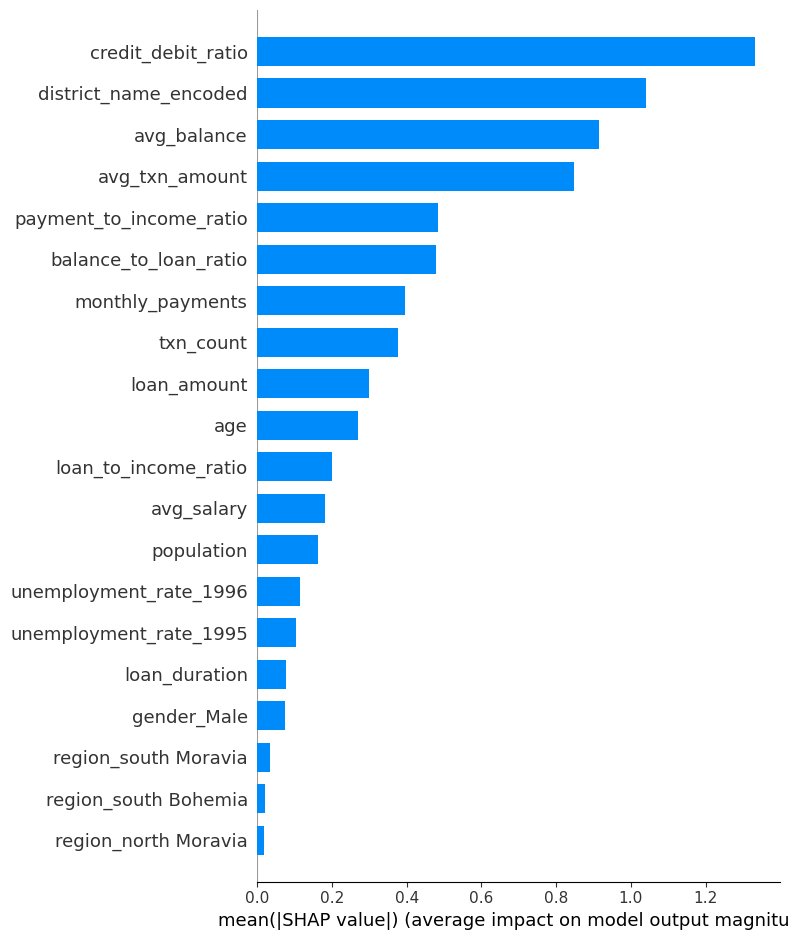

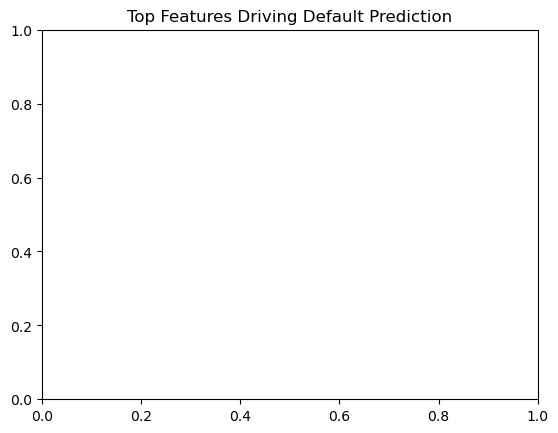

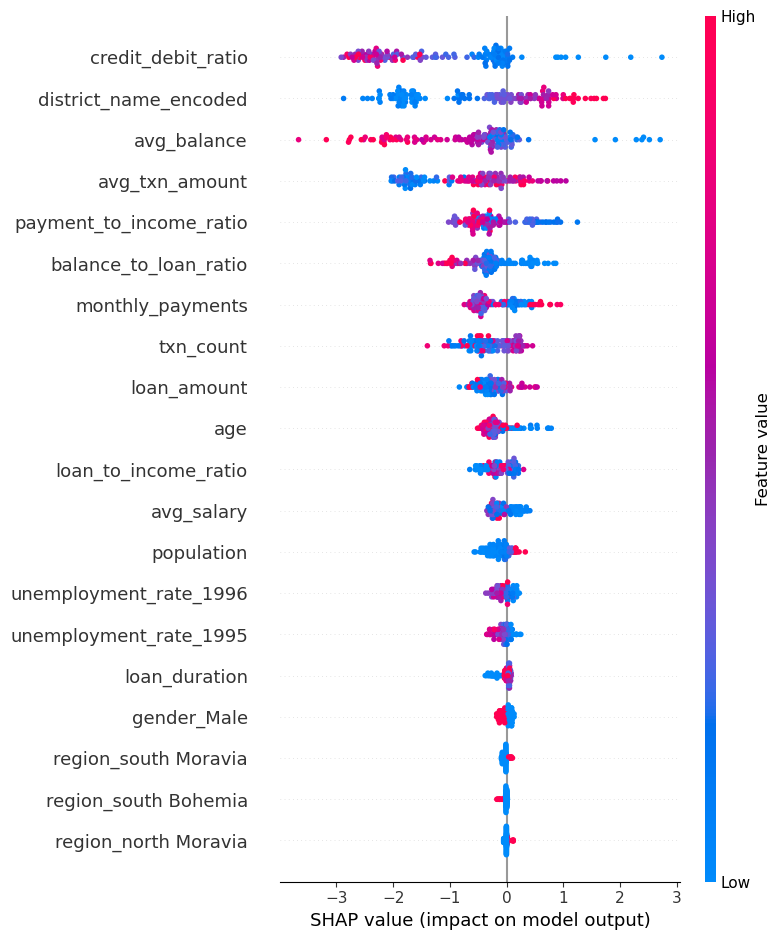

In [54]:
import shap
import matplotlib.pyplot as plt

# Create explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(Xtest_scaled)

# 1. Summary Plot (Global Feature Importance)
shap.summary_plot(shap_values, Xtest_scaled, plot_type="bar")
plt.title("Top Features Driving Default Prediction")
plt.show()

# 2. Detailed Summary Plot
shap.summary_plot(shap_values, Xtest_scaled)
plt.show()

**Key Insights from SHAP Analysis**

Top Drivers of Loan Default:

* credit_debit_ratio → Highest impact (most important)
* district_name_encoded → Strong regional effect
* avg_balance → Low balance significantly increases risk
* avg_txn_amount → Low transaction amount is risky
* payment_to_income_ratio → High burden increases default risk
* balance_to_loan_ratio → Low balance relative to loan is dangerous